In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.ndimage import median_filter
from skimage import exposure

from scipy.ndimage import binary_fill_holes, gaussian_filter
from skimage.feature import peak_local_max
from skimage.measure import label
from skimage.morphology import white_tophat, disk
from scipy.ndimage import gaussian_filter, median_filter

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "Image-Preprocessing").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT: raise FileNotFoundError("Could not find project root containing Image-Preprocessing")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "Image-Preprocessing"))

import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import detection_algorithms as da
import detection_errors as de
import biology_algorithms as ba

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


# Loading the scans

In [6]:
import pandas as pd

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

from skimage.measure import label, regionprops

afm_files = [
    Path("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data.npy"),
    Path("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data.npy"),
]

titles = [ "AFM scan 1", "AFM scan 2", "AFM scan 3",]

raw_scans = []
processed_scans = []

for path in afm_files:
    z = np.load(path)
    z = np.asarray(z, dtype=float)

    z_processed, stages = bdp.preprocess_afm(
        z,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    raw_scans.append(z)
    processed_scans.append(z_processed)


def centres_from_binary_mask(binary_mask):
    binary_mask = np.asarray(binary_mask, dtype=bool)

    labelled_mask = label(binary_mask, connectivity=2,)

    centres = [region.centroid for region in regionprops(labelled_mask)]

    if not centres:
        return np.empty((0, 2), dtype=float)

    return np.asarray(centres, dtype=float)

dataset = {}
ground_truth_masks = [
    np.load("Ground-Truth/NPY-Ground-Truth/Scan1/channel_00___0_data_mask.npy"),
    np.load("Ground-Truth/NPY-Ground-Truth/Scan2/channel_00___0_data_mask.npy"),
    np.load("Ground-Truth/NPY-Ground-Truth/Scan3/channel_00___0_data_mask.npy"),
]

for scan_name, raw, processed, mask in zip(
    ["Scan1", "Scan2", "Scan3"],
    raw_scans,
    processed_scans,
    ground_truth_masks,
):
    ground_truth_centres = centres_from_binary_mask(mask)

    dataset[scan_name] = {
        "raw": raw,
        "processed": processed,
        "ground_truth_mask": mask,
        "ground_truth_centres": ground_truth_centres,
    }

    print(
        scan_name,
        "ground-truth QDs:",
        len(ground_truth_centres),
    )

Scan1 ground-truth QDs: 133
Scan2 ground-truth QDs: 137
Scan3 ground-truth QDs: 135


In [7]:
from IPython.display import display
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy import ndimage
from scipy.spatial import KDTree
from skimage.measure import label, regionprops
from skimage.morphology import remove_small_objects
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "Ground-Truth").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT: raise FileNotFoundError("Could not find project root containing Ground-Truth")
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "Ground-Truth"))

import feature_evaluation as fe

print("PROJECT_ROOT:", PROJECT_ROOT)

# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)


# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)# LOAD SCAN 3
scan_folder = PROJECT_ROOT / "Ground-Truth/NPY-Ground-Truth/Scan3"
image = np.load(scan_folder / "channel_00___0_data.npy")
Y_test = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)


# PREPROCESS
image_preprocessed, _ = bdp.preprocess_afm(image, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
X_test = bdp.robust_normalise(image_preprocessed)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


# Adding biological algorithms comparison

### Stardist

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


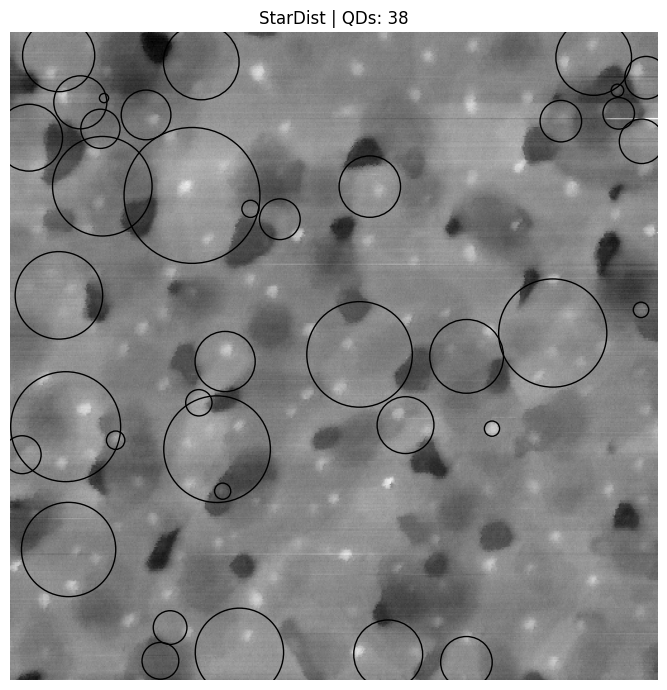

In [8]:
result_stardist = ba.stardist_detect(
    X_test,
    prob_thresh=0.5,
    nms_thresh=0.8,
)

ba.draw_qd_result(
    X_test,
    result_stardist,
    title=f"StarDist | QDs: {result_stardist['n_qds']}",
)

### Cellpose

2026-08-17 12:50:23,183	[INFO]     cellpose/core.py              assi...evice()	 line 101	>>>> using CPU
2026-08-17 12:50:23,183	[INFO]                                               	 line 107	>>>> using CPU
2026-08-17 12:50:23,865	[INFO]     cellpose/models.py            __init__....()	 line 163	>>>> loading model /Users/polinabobrova/.cellpose/models/cpsam_v2


dynamics.py (541): Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:823.)


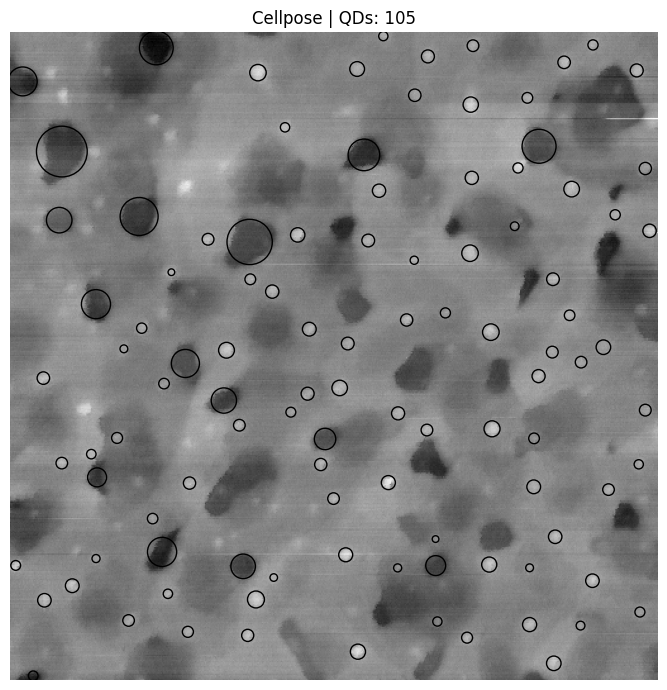

In [13]:
import importlib
import biology_algorithms as ba

importlib.reload(ba)

result_cellpose = ba.cellpose_detect(
    X_test,
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    min_size=3,
)

ba.draw_qd_result(
    X_test,
    result_cellpose,
    title=f"Cellpose | QDs: {result_cellpose['n_qds']}",
)

### Micro SAM

Using apple MPS device.


Initialize instance segmentation with decoder: 100%|██████████| 1/1 [00:00<00:00,  2.64it/s]


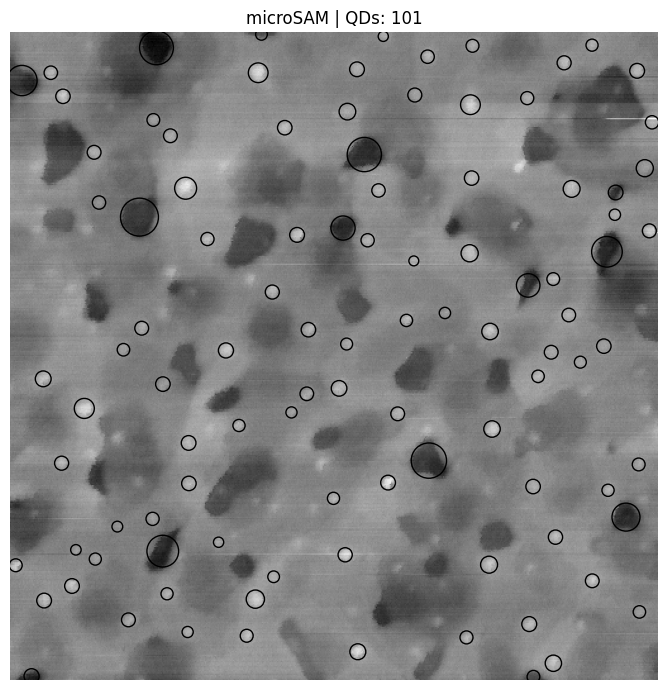

In [11]:
result_microsam = ba.microsam_detect(
    X_test,
    segmentation_mode="apg",
)

ba.draw_qd_result(
    X_test,
    result_microsam,
    title=f"microSAM | QDs: {result_microsam['n_qds']}",
)

### R-CNN

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /Users/polinabobrova/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s] 


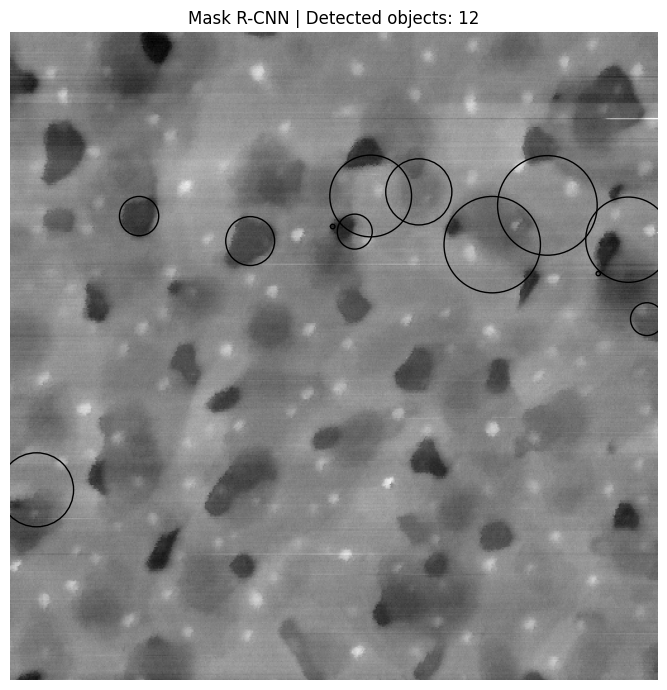

In [12]:
result_maskrcnn = ba.maskrcnn_detect(
    image_preprocessed,
    score_threshold=0.5,
    mask_threshold=0.5,
    gpu=True,
)

ba.draw_qd_result(
    image_preprocessed,
    result_maskrcnn,
    title=(
        f"Mask R-CNN | "
        f"Detected objects: {result_maskrcnn['n_qds']}"
    ),
)

# Algorithm Evaluation

In [ ]:
# RUN BIOLOGY ALGORITHMS

biology_algorithm_results = {}

biology_algorithm_results["StarDist"] = ba.stardist_detect(
    image_preprocessed
)

biology_algorithm_results["Cellpose"] = ba.cellpose_detect(
    image_preprocessed,
    cellprob_threshold=0.0,
    flow_threshold=0.4,
    min_size=3,
)

biology_algorithm_results["MicroSAM"] = ba.microsam_detect(
    image_preprocessed,
    segmentation_mode="apg",
)

biology_algorithm_results["RCNN"] = ba.maskrcnn_detect(
    image_preprocessed,
    score_threshold=0.5,
    mask_threshold=0.5,
    gpu=False,
)

Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
2026-08-17 12:59:12,507	[INFO]     cellpose/core.py              assi...evice()	 line 101	>>>> using CPU
2026-08-17 12:59:12,508	[INFO]                                               	 line 107	>>>> using CPU
2026-08-17 12:59:13,126	[INFO]     cellpose/models.py            __init__....()	 line 163	>>>> loading model /Users/polinabobrova/.cellpose/models/cpsam_v2


TypeError: Cellpose.__init__() got an unexpected keyword argument 'nclasses'

In [ ]:
# EVALUATE CLASSICAL ALGORITHMS
rows = []
for algorithm_name, result in biology_algorithm_results.items():
    for stage in ["before_height_filter", "after_height_filter"]:
        metrics = fe.evaluate_feature_masks(Y_test, result[stage]["mask"], tolerance=3.0)
        rows.append({"Algorithm": algorithm_name, "Stage": stage, **metrics})


# LOAD U-NET
model = tf.keras.models.load_model(PROJECT_ROOT / "Ground-Truth/qd_unet_fold1.keras", compile=False)

# U-NET PREDICTION
prediction = fe.predict_full_scan(model, X_test, patch_size=128)


# EVALUATE U-NET AT YOUR CURRENT THRESHOLD
unet_threshold = 0.20
unet_mask = remove_small_objects(prediction >= unet_threshold, min_size=1)
unet_metrics = fe.evaluate_feature_masks(Y_test, unet_mask, tolerance=3.0)
rows.append({"Algorithm": "U-Net", "Stage": f"threshold={unet_threshold:.2f}", **unet_metrics})


In [ ]:
# FINAL TABLE
results_df = pd.DataFrame(rows)
results_df = results_df[["Algorithm", "Stage", "GT count", "Predicted count", "TP", "FP", "FN", "Precision", "Recall", "F1"]]
print(results_df.sort_values("F1", ascending=False).to_string(index=False))

     Algorithm                Stage  GT count  Predicted count  TP   FP  FN  Precision   Recall       F1
         U-Net       threshold=0.20       138              136 117   19  21   0.860294 0.847826 0.854015
     Watershed  after_height_filter       138              185 116   69  22   0.627027 0.840580 0.718266
     Chambolle  after_height_filter       138              138  99   39  39   0.717391 0.717391 0.717391
          Otsu  after_height_filter       138              147 101   46  37   0.687075 0.731884 0.708772
           LoG  after_height_filter       138              136  97   39  41   0.713235 0.702899 0.708029
Phase symmetry  after_height_filter       138              101  74   27  64   0.732673 0.536232 0.619247
          SIFT  after_height_filter       138               72  60   12  78   0.833333 0.434783 0.571429
           LoG before_height_filter       138              211  93  118  45   0.440758 0.673913 0.532951
         Gabor  after_height_filter       138          

In [ ]:
# TEST U-NET OBJECT-LEVEL F1 ACROSS THRESHOLDS
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.05):
    mask = remove_small_objects(prediction >= threshold, min_size=1)
    metrics = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    threshold_rows.append({"Threshold": threshold, **metrics})

unet_threshold_df = pd.DataFrame(threshold_rows)
print("\nU-NET THRESHOLD SWEEP:")
print(unet_threshold_df.sort_values("F1", ascending=False).to_string(index=False))

best = unet_threshold_df.loc[unet_threshold_df["F1"].idxmax()]
print("\nBest U-Net threshold on this scan:")
print(best)


U-NET THRESHOLD SWEEP:
 Threshold  TP  FP  FN  GT count  Predicted count  Precision   Recall       F1
      0.20 117  19  21       138              136   0.860294 0.847826 0.854015
      0.30 114  16  24       138              130   0.876923 0.826087 0.850746
      0.05 124  30  14       138              154   0.805195 0.898551 0.849315
      0.15 117  22  21       138              139   0.841727 0.847826 0.844765
      0.10 119  26  19       138              145   0.820690 0.862319 0.840989
      0.25 115  21  23       138              136   0.845588 0.833333 0.839416
      0.35 112  18  26       138              130   0.861538 0.811594 0.835821
      0.70 109  14  29       138              123   0.886179 0.789855 0.835249
      0.60 109  15  29       138              124   0.879032 0.789855 0.832061
      0.50 110  17  28       138              127   0.866142 0.797101 0.830189
      0.40 110  17  28       138              127   0.866142 0.797101 0.830189
      0.65 108  15  30      

In [ ]:
# ADD U-NET TO THE SAME RESULTS DICTIONARY SO IT CAN BE DISPLAYED WITH EVERYTHING
unet_mask = remove_small_objects(prediction >= 0.20, min_size=1)
algorithm_results["U-Net"] = {"before_height_filter": {"mask": unet_mask}, "after_height_filter": {"mask": unet_mask}}

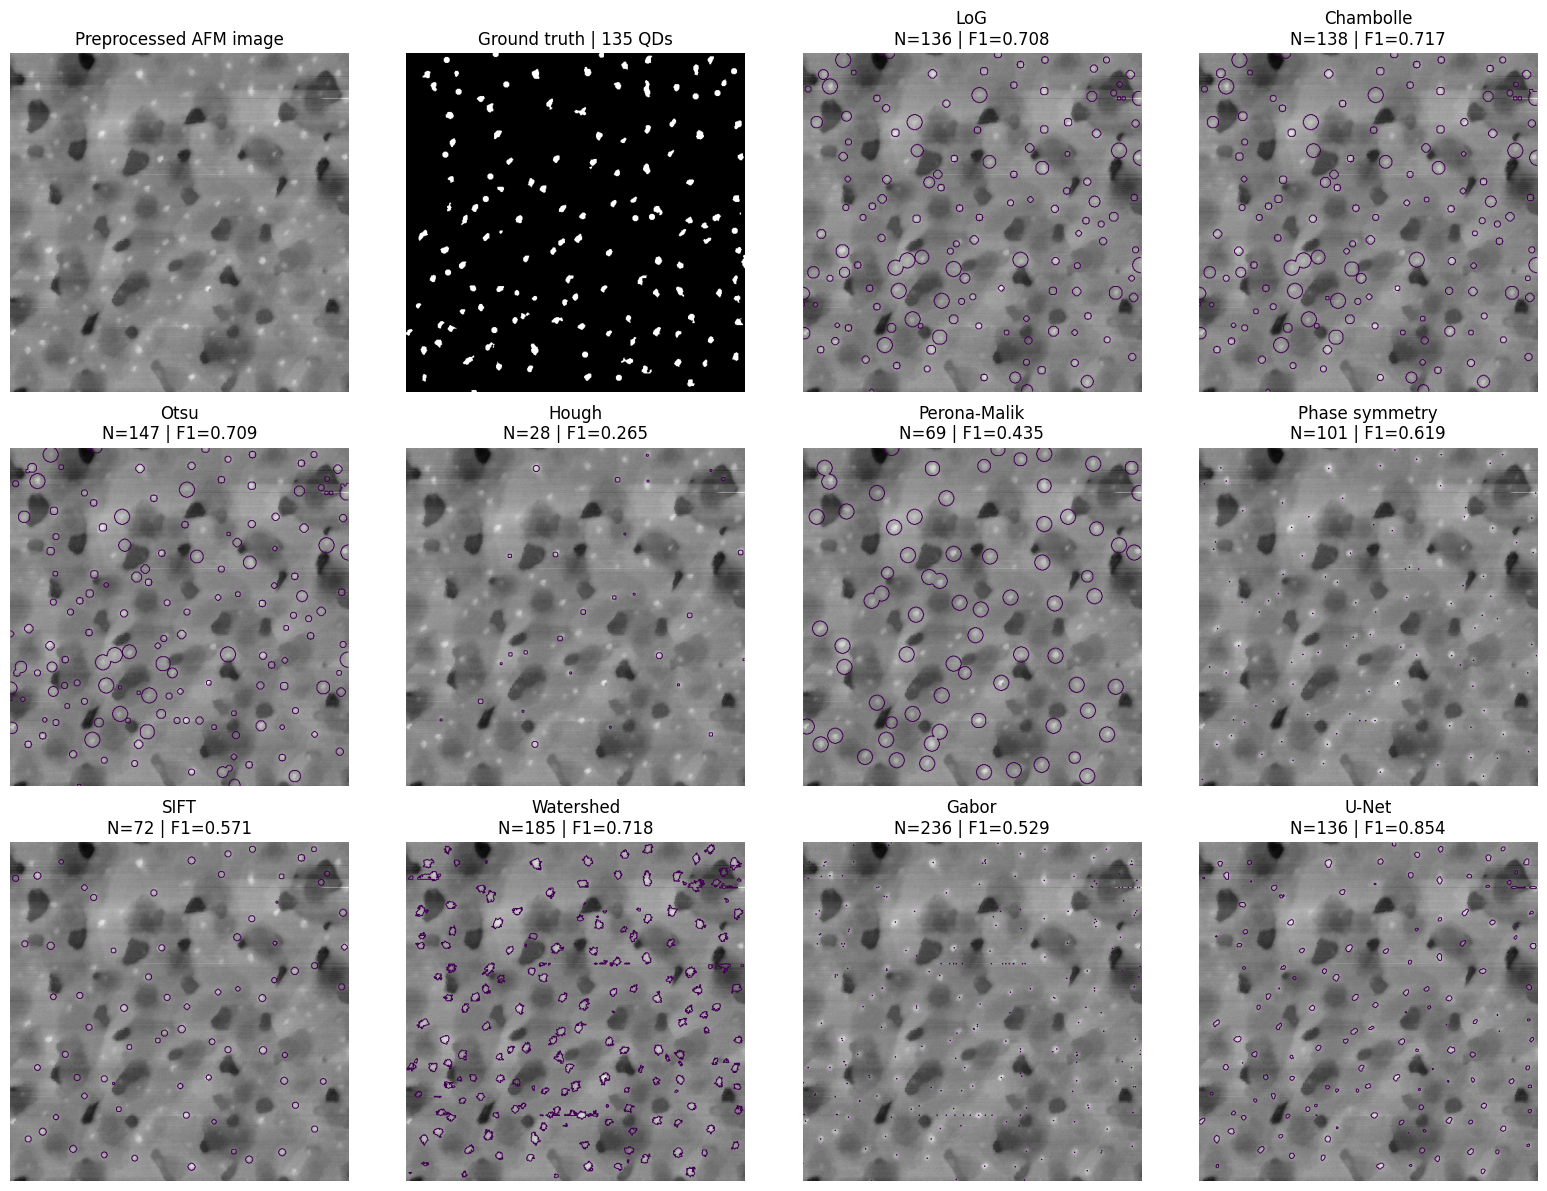

In [ ]:
# DISPLAY ALL ALGORITHM MASKS BESIDE THE GROUND TRUTH
display_stage = "after_height_filter"
names = list(algorithm_results.keys())
ncols = 4
nrows = int(np.ceil((len(names) + 2) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.asarray(axes).ravel()

axes[0].imshow(X_test, cmap="gray"); axes[0].set_title("Preprocessed AFM image"); axes[0].axis("off")
axes[1].imshow(Y_test, cmap="gray"); axes[1].set_title(f"Ground truth | {ndimage.label(Y_test, structure=np.ones((3,3)))[1]} QDs"); axes[1].axis("off")

for ax, name in zip(axes[2:], names):
    mask = algorithm_results[name][display_stage]["mask"]
    metrics = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    ax.imshow(X_test, cmap="gray"); ax.contour(mask, levels=[0.5], linewidths=0.7)
    ax.set_title(f"{name}\nN={metrics['Predicted count']} | F1={metrics['F1']:.3f}"); ax.axis("off")

for ax in axes[len(names)+2:]: ax.axis("off")
plt.tight_layout(); plt.show()

### DISPLAY ERROR OVERLAY FOR EVERY ALGORITHM

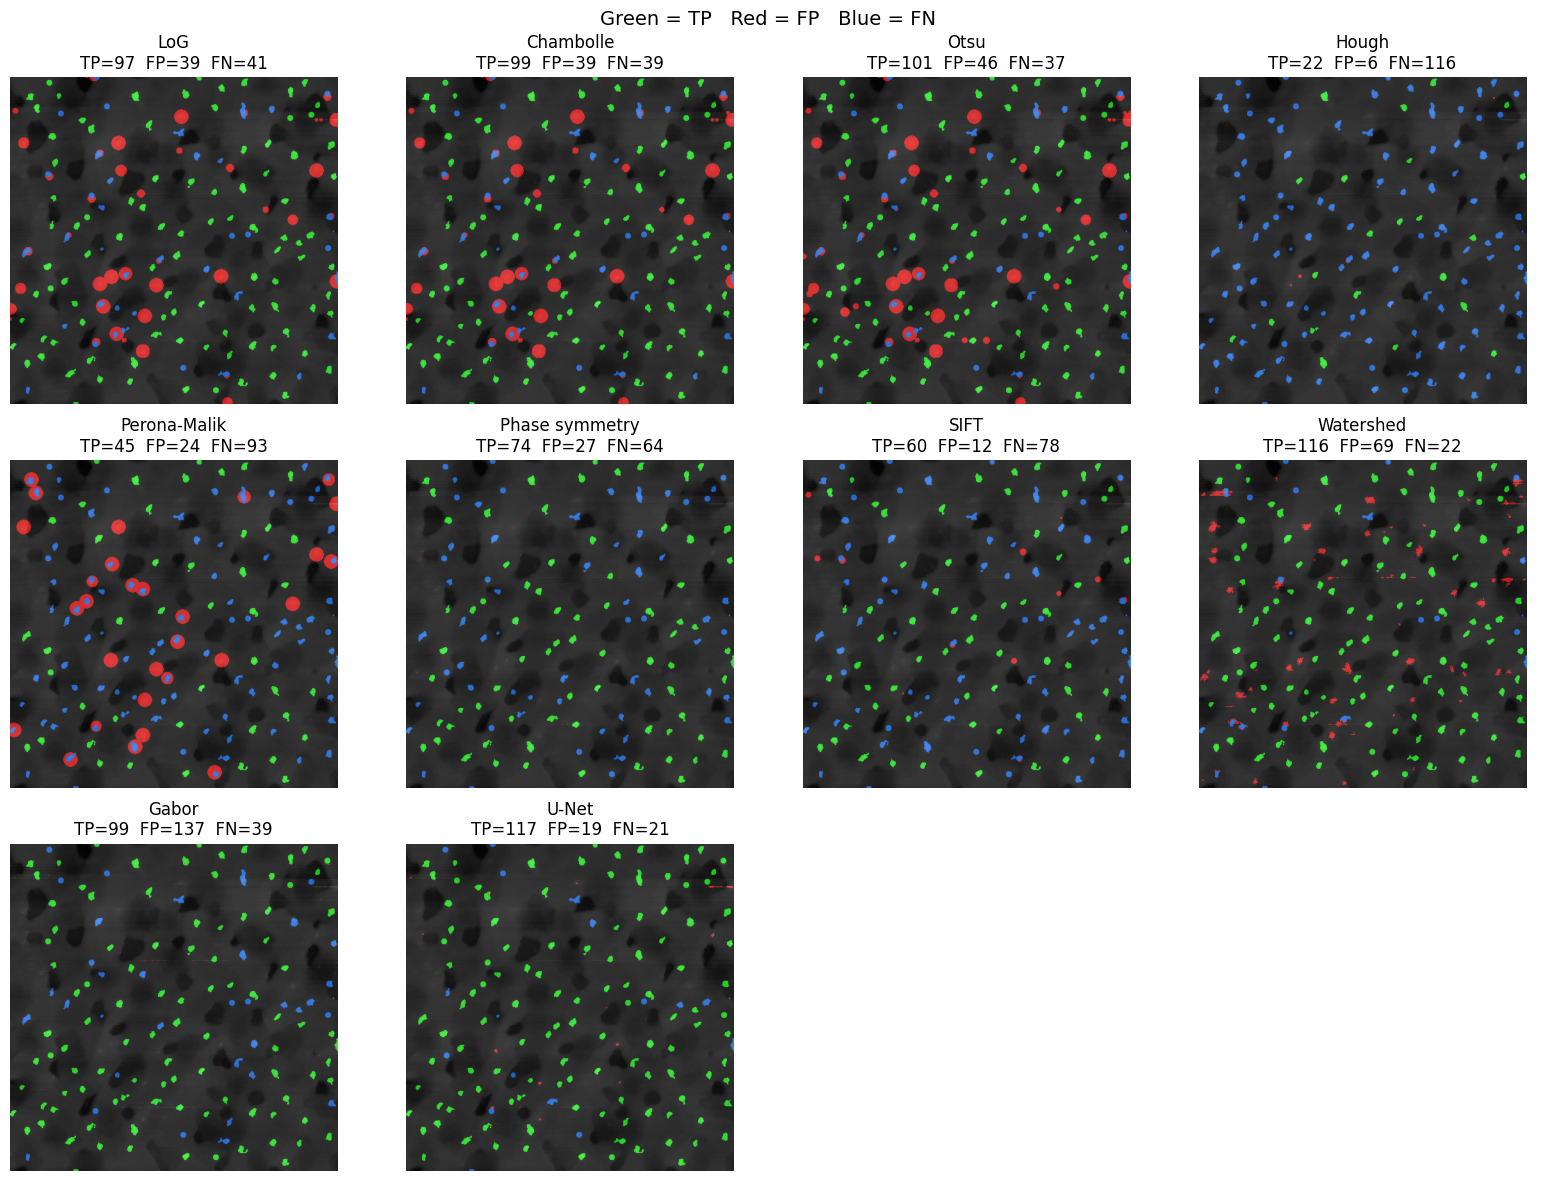

In [ ]:
ncols = 4
nrows = int(np.ceil(len(names)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows))
axes = np.asarray(axes).ravel()

for ax, name in zip(axes, names):
    mask = algorithm_results[name][display_stage]["mask"]
    metrics = fe.evaluate_feature_masks(Y_test, mask, tolerance=3.0)
    ax.imshow(X_test, cmap="gray")
    ax.imshow(fe.make_error_overlay(Y_test, mask), alpha=0.65)
    ax.set_title(f"{name}\nTP={metrics['TP']}  FP={metrics['FP']}  FN={metrics['FN']}"); ax.axis("off")

for ax in axes[len(names):]: ax.axis("off")
fig.suptitle("Green = TP   Red = FP   Blue = FN", fontsize=14)
plt.tight_layout(); plt.show()

### PRECISION / RECALL / F1 BAR GRAPH

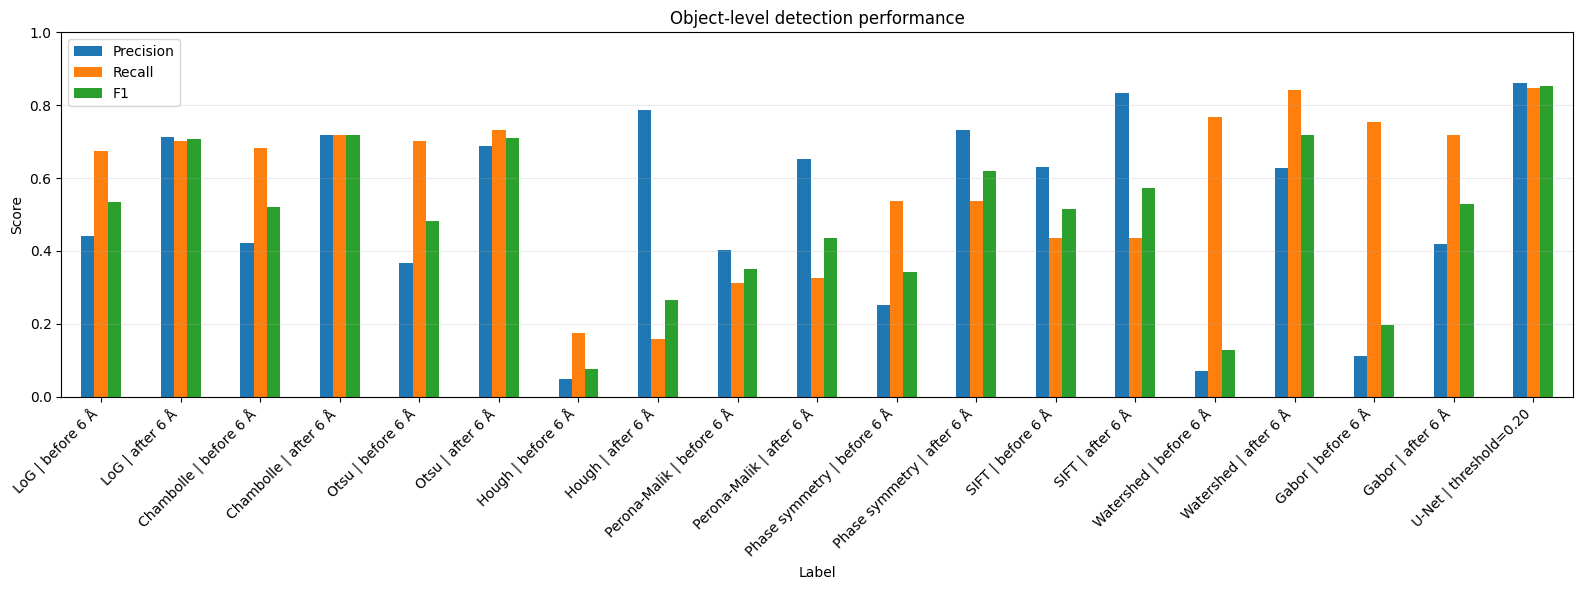

In [ ]:
plot_df = results_df.copy()

plot_df["Label"] = plot_df["Algorithm"] + " | " + plot_df["Stage"].replace({"before_height_filter":"before 6 Å", "after_height_filter":"after 6 Å"})
metric_df = plot_df.set_index("Label")[["Precision","Recall","F1"]]

ax = metric_df.plot(kind="bar", figsize=(16,6))
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.set_title("Object-level detection performance")
ax.grid(axis="y", alpha=0.25); plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### TP / FP / FN BAR GRAPH

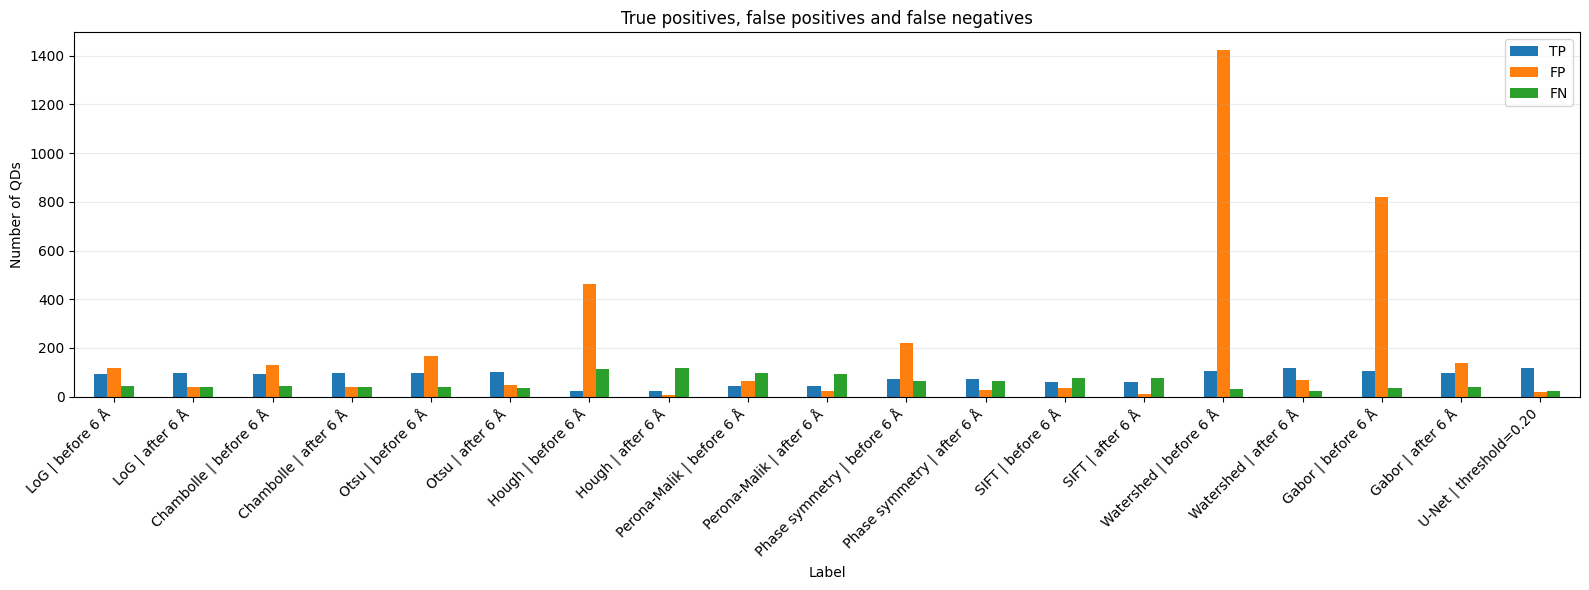

In [ ]:
count_df = plot_df.set_index("Label")[["TP","FP","FN"]]
ax = count_df.plot(kind="bar", figsize=(16,6))

ax.set_ylabel("Number of QDs")
ax.set_title("True positives, false positives and false negatives")
ax.grid(axis="y", alpha=0.25) 
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


### ACTUAL PREDICTED COUNT AGAINST GROUND-TRUTH COUNT

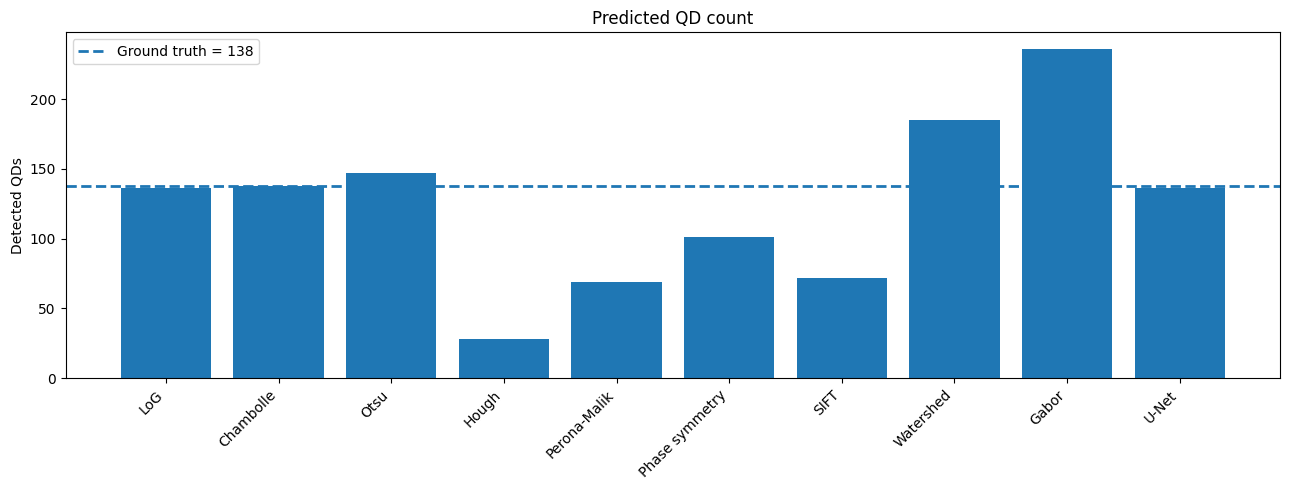

In [ ]:
after_df = results_df[(results_df["Stage"] == "after_height_filter") | (results_df["Algorithm"] == "U-Net")].copy()
fig, ax = plt.subplots(figsize=(13,5))
x = np.arange(len(after_df))
ax.bar(x, after_df["Predicted count"])

ax.axhline(after_df["GT count"].iloc[0], 
           linestyle="--", 
           linewidth=2, 
           label=f"Ground truth = {after_df['GT count'].iloc[0]}")

ax.set_xticks(x)
ax.set_xticklabels(after_df["Algorithm"], rotation=45, ha="right")
ax.set_ylabel("Detected QDs")
ax.set_title("Predicted QD count")
ax.legend() 

plt.tight_layout()
plt.show()

### SORTED F1 GRAPH — SIMPLE OVERALL RANKING

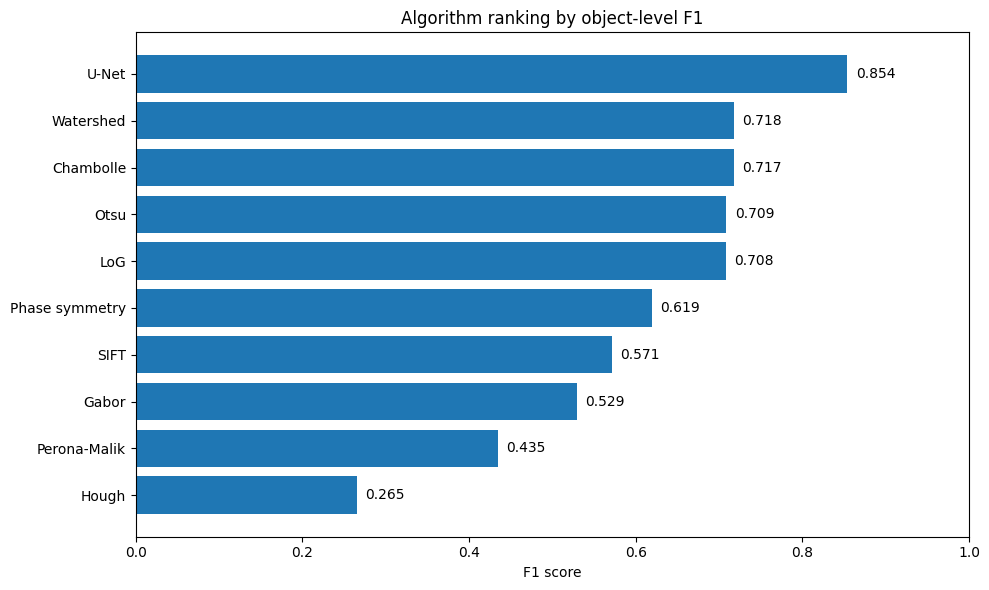

In [ ]:
ranking = after_df.sort_values("F1", ascending=True)
fig, ax = plt.subplots(figsize=(10,6))
ax.barh(ranking["Algorithm"], ranking["F1"])

ax.set_xlim(0,1)
ax.set_xlabel("F1 score")
ax.set_title("Algorithm ranking by object-level F1")

for i, value in enumerate(ranking["F1"]): 
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

plt.tight_layout() 
plt.show()